Mounted at /content/drive


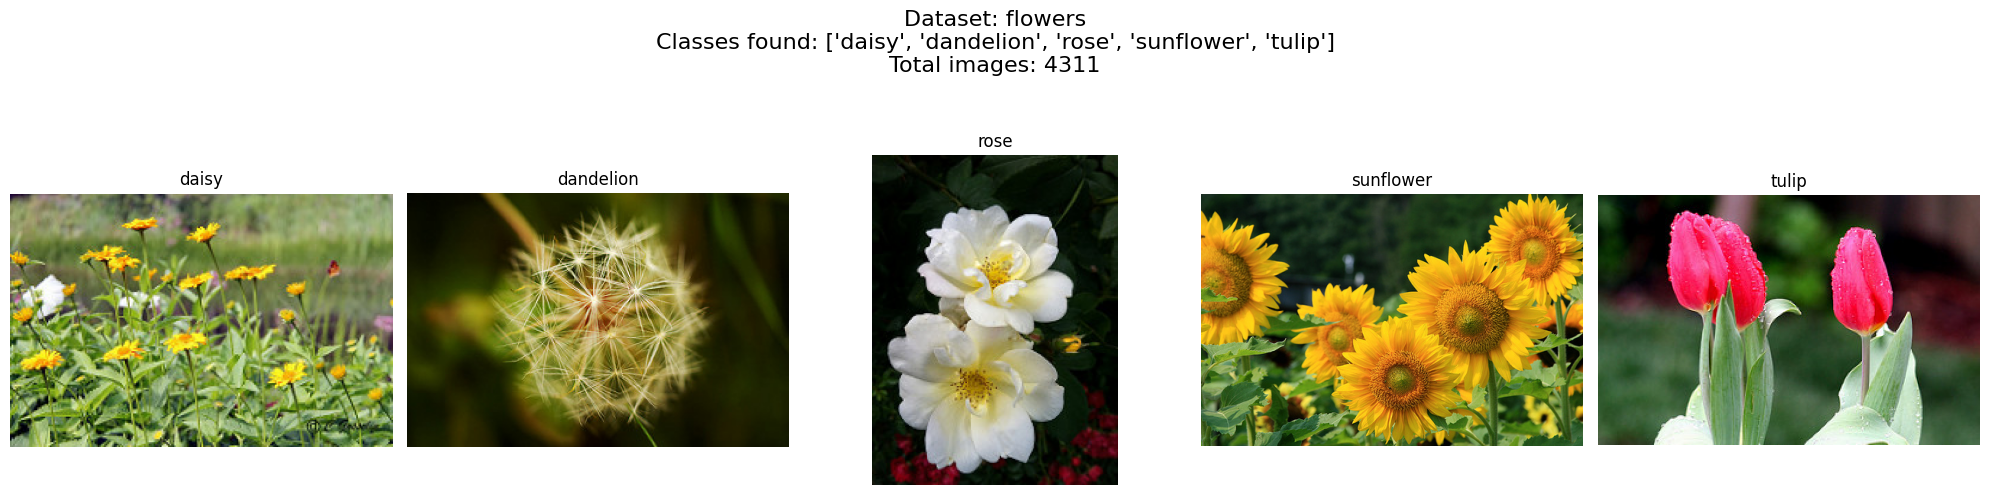

In [ ]:
from google.colab import drive
import zipfile
import os
from matplotlib import pyplot as plt
import cv2

# Mount Drive
drive.mount('/content/drive', force_remount=True)

# Paths
zip_path = "/content/drive/MyDrive/Datasets/archive.zip"
extract_path = "/content/drive/MyDrive/Datasets/flowers"

# Extract ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Detect actual class folders
data_dir = extract_path
possible_subfolders = os.listdir(data_dir)
if len(possible_subfolders) == 1 and os.path.isdir(os.path.join(data_dir, possible_subfolders[0])):
    data_dir = os.path.join(data_dir, possible_subfolders[0])

classes = [cls for cls in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, cls))]

# Count total images
total_images = 0
class_images = {}
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    class_images[cls] = imgs
    total_images += len(imgs)

# Plot samples + add text on top
num_classes = len(classes)
plt.figure(figsize=(4*num_classes, 5))

# Add text at the top
plt.suptitle(f"Dataset: flowers\nClasses found: {classes}\nTotal images: {total_images}", fontsize=16)

for i, cls in enumerate(classes):
    imgs = class_images[cls]
    if imgs:
        img_path = os.path.join(data_dir, cls, imgs[0])
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(1, num_classes, i+1)
            plt.imshow(img)
            plt.title(cls)
            plt.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.9])  # leave space for suptitle
plt.show()




Mounted at /content/drive
Found 3020 images belonging to 5 classes.
Found 1291 images belonging to 5 classes.


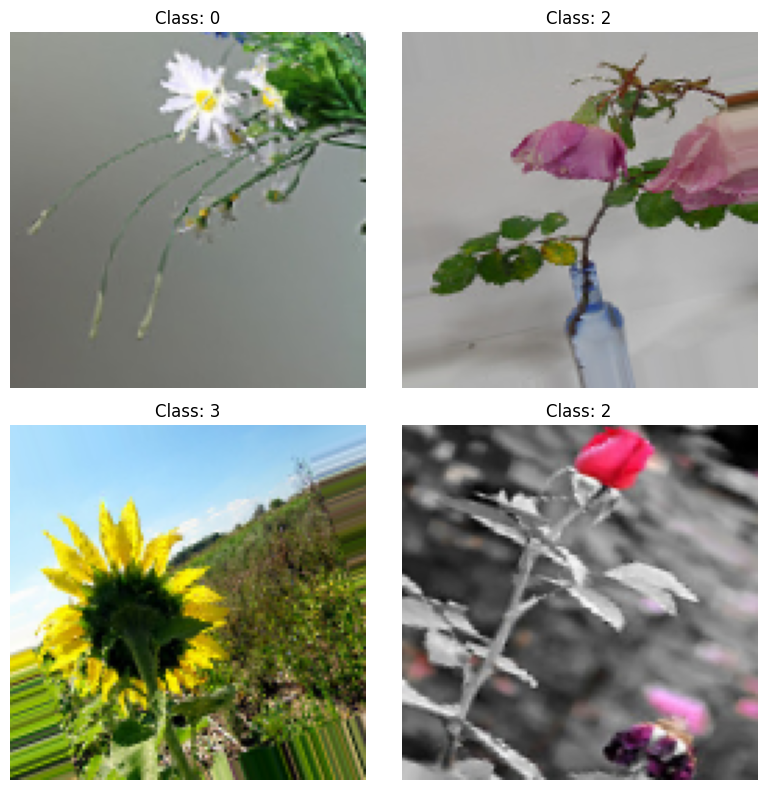

Number of training samples: 3020
Number of validation samples: 1291


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import zipfile
import os
from google.colab import drive

# Step 1: Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Step 2: Path to ZIP file in Drive
zip_path = "/content/drive/MyDrive/Datasets/archive.zip"
extract_path = "/content/flowers"

# Step 3: Extract ZIP if folder doesn't exist
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("/content")
    os.rename("/content/flowers", extract_path)

# Step 4: Set parameters
data_dir = extract_path
img_size = (128, 128)
batch_size = 32

# Step 5: Data generators with augmentation and train/validation split
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.3
)

train_set = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

val_set = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

# Step 6: Visualize 4 augmented samples
x_batch, y_batch = next(train_set)
plt.figure(figsize=(8, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(x_batch[i])
    cls_idx = y_batch[i].argmax()
    plt.title(f"Class: {cls_idx}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Step 7: Print dataset sizes
print("Number of training samples:", train_set.samples)
print("Number of validation samples:", val_set.samples)



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

img_size = (128, 128)
input_shape = (img_size[0], img_size[1], 3)
num_classes = 5

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),  # thoda bada Dense layer for better learning
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

epochs = 15
history = model.fit(
    train_set,
    validation_data=val_set,
    epochs=epochs
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,317 (24.86 MB)

 Trainable params: 6,517,317 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.3330 - loss: 1.4923 - val_accuracy: 0.5143 - val_loss: 1.1334
Epoch 2/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.5516 - loss: 1.0802 - val_accuracy: 0.5941 - val_loss: 0.9991
Epoch 3/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.5861 - loss: 1.0194 - val_accuracy: 0.6452 - val_loss: 0.8947
Epoch 4/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.6652 - loss: 0.8805 - val_accuracy: 0.6561 - val_loss: 0.8676
Epoch 5/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.6859 - loss: 0.8225 - val_accuracy: 0.6050 - val_loss: 1.0735
Epoch 6/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.6984 - loss: 0.7782 - val_accuracy: 0.6824 - val_loss: 0.8497
Epoch 7/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.7265 - loss: 0.7106 - val_accuracy: 0.6824 - val_loss: 0.8227
Epoch 8/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.7245 - loss: 0.7146 - val_accuracy: 0.6878 - v

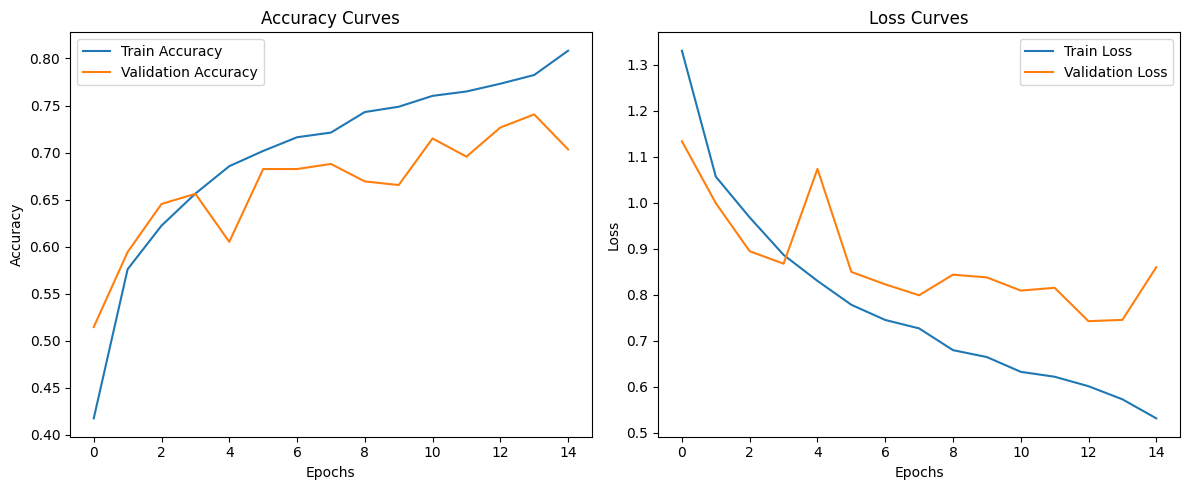

41/41 ━━━━━━━━━━━━━━━━━━━━ 17s 416ms/step


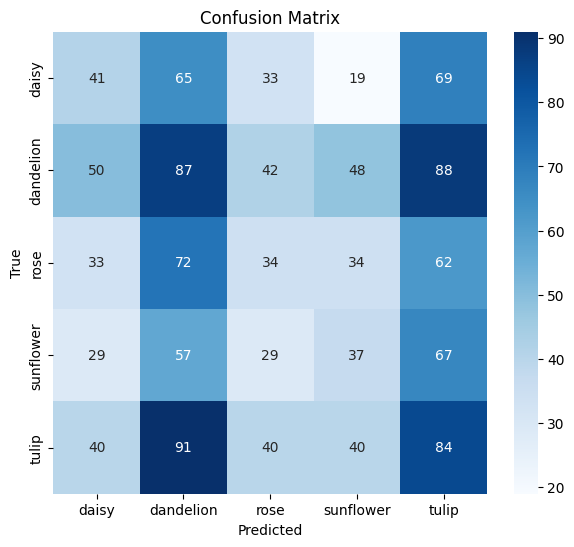

Classification Report:
               precision    recall  f1-score   support

       daisy       0.21      0.18      0.20       227
   dandelion       0.23      0.28      0.25       315
        rose       0.19      0.14      0.16       235
   sunflower       0.21      0.17      0.19       219
       tulip       0.23      0.28      0.25       295

    accuracy                           0.22      1291
   macro avg       0.21      0.21      0.21      1291
weighted avg       0.22      0.22      0.22      1291



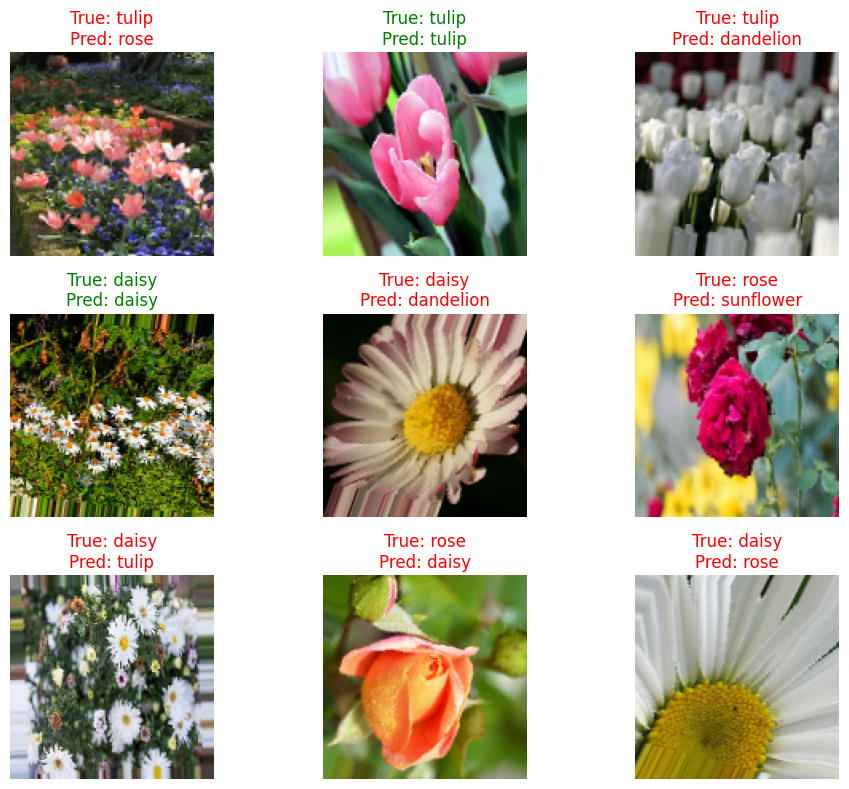

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns

# 1. Plot accuracy and loss curves
history = model.history.history
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 2. Predictions on validation set
val_set.reset()
y_pred_prob = model.predict(val_set)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_set.classes
class_labels = list(val_set.class_indices.keys())

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 4. Classification Report
report = classification_report(y_true, y_pred, target_names=class_labels)
print("Classification Report:\n", report)

# 5. Correct vs Incorrect Predictions Visualization
x_val, y_val = next(val_set)
y_val_class = np.argmax(y_val, axis=1)
plt.figure(figsize=(10,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_val[i])
    pred_label = class_labels[y_pred[i]]
    true_label = class_labels[y_val_class[i]]
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving archive (1).zip to archive (1).zip


In [ ]:
import zipfile
import os

zip_name = list(uploaded.keys())[0]
extract_path = "/content/birds"

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted at:", extract_path)


Dataset extracted at: /content/birds


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.3
)

train_set = datagen.flow_from_directory(
    "/content/birds/train",
    target_size=img_size,
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

val_set = datagen.flow_from_directory(
    "/content/birds/train",
    target_size=img_size,
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

num_classes = train_set.num_classes
print("Total bird species:", num_classes)


Found 2254 images belonging to 20 classes.
Found 954 images belonging to 20 classes.
Total bird species: 20


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,521,172 (24.88 MB)

 Trainable params: 6,521,172 (24.88 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 10

history = model.fit(
    train_set,
    validation_data=val_set,
    epochs=epochs
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.0729 - loss: 3.0641 - val_accuracy: 0.2841 - val_loss: 2.3964
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.2707 - loss: 2.3034 - val_accuracy: 0.4748 - val_loss: 1.6914
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.4469 - loss: 1.7609 - val_accuracy: 0.5147 - val_loss: 1.6776
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.5056 - loss: 1.5894 - val_accuracy: 0.5734 - val_loss: 1.4321
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.5609 - loss: 1.3772 - val_accuracy: 0.5849 - val_loss: 1.3715
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.5701 - loss: 1.3054 - val_accuracy: 0.6164 - val_loss: 1.3045
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.6139 - loss: 1.2389 - val_accuracy: 0.6394 - val_loss: 1.2036
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.6390 - loss: 1.1388 - val_accuracy: 0.6101 - val

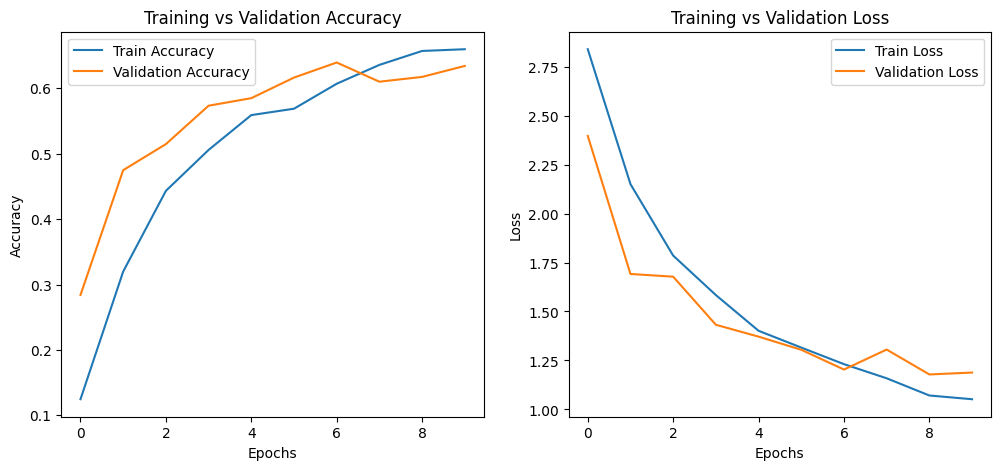

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 961ms/step


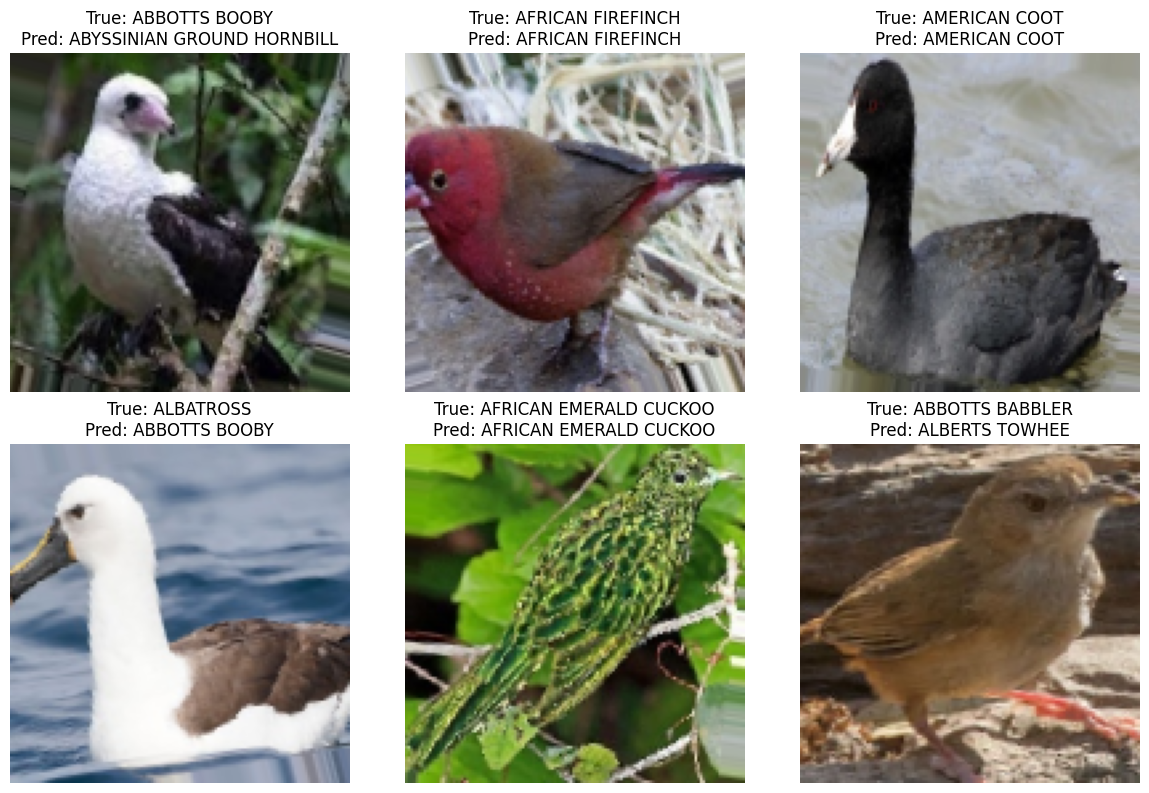

In [ ]:
import numpy as np

class_names = list(train_set.class_indices.keys())

images, labels = next(val_set)
preds = model.predict(images)

plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    true_label = class_names[np.argmax(labels[i])]
    pred_label = class_names[np.argmax(preds[i])]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()


30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 492ms/step


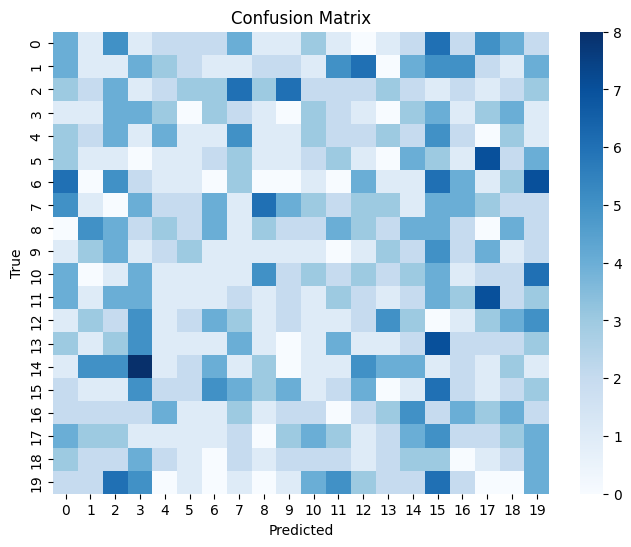

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

val_set.reset()
predictions = model.predict(val_set)
y_pred = predictions.argmax(axis=1)
y_true = val_set.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
